In [ ]:
# Unpickling the data
import pickle

with open('/content/Images.p', 'rb') as f:
    Images = pickle.load(f)
with open('/content/labels.p', 'rb') as f:
    labels = pickle.load(f)

In [ ]:
print(Images.shape)
print(labels.shape)

(199,100,100)
(199,)

(200, 100, 100)
(200,)


(199,)

In [ ]:
labels

array(['Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit', 'Ronit',
       'Ronit', 'Ron

In [ ]:
set(labels)

{np.str_('Ronit'), np.str_('Tammana')}

In [ ]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [ ]:
labels = le.fit_transform(labels)
set(labels)


{np.int64(0), np.int64(1)}

In [ ]:
le.inverse_transform([0,1])


array(['Ronit', 'Tammana'], dtype='<U7')

In [ ]:
print(le.classes_)

['Ronit' 'Tammana']


In [ ]:
p = len(set(labels))
print("Toatal number of persons: ",p)

Toatal number of persons:  2


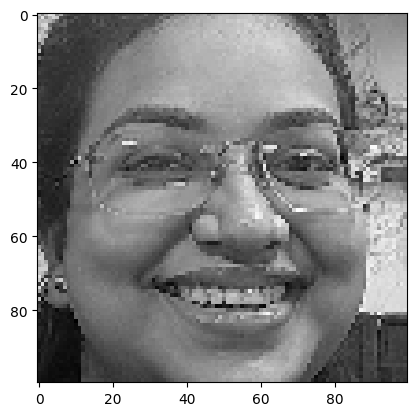

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(Images[155],cmap='gray')
plt.show()

In [ ]:
import cv2

In [ ]:
from numpy import reshape
def preprocessing(img):
  img = cv2.equalizeHist(img)
  img = img.reshape(100,100,1)
  img = img/255
  return img


In [ ]:
import numpy as np

In [ ]:
images = np.array(list(map(preprocessing,Images)))
print("Shape of Input Data:",images.shape)



Shape of Input Data: (200, 100, 100, 1)


In [ ]:
from keras.utils import to_categorical
labels = to_categorical(labels)



In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(images,labels,test_size=0.2)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.layers import Conv2D,MaxPooling2D,Flatten


In [ ]:
model = Sequential()
#convolutional and Relu Layer
model.add(Conv2D(32,(3,3),input_shape=(100,100,1),activation='relu'))
# Pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

#Convolutional layer and ReLU layer
model.add(Conv2D(64,(3,3),activation="relu"))
#Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

#Flatten Layer/Input Layer
model.add(Flatten())

#Hidden Layer
model.add(Dense(200,activation='relu'))
model.add(Dense(100,activation = 'relu'))

#Output Layer
model.add(Dense(p,activation='softmax'))
model.compile(Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │     6,771,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,810,518 (25.98 MB)

 Trainable params: 6,810,518 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test, y_test),verbose=1)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 568ms/step - accuracy: 0.4313 - loss: 7.6753 - val_accuracy: 0.6250 - val_loss: 0.6453
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.7500 - loss: 0.5262 - val_accuracy: 1.0000 - val_loss: 0.1597
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step - accuracy: 0.9937 - loss: 0.1002 - val_accuracy: 1.0000 - val_loss: 0.0084
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 427ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5.9902e-07
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 1.0000 - loss: 1.1027e-07 - val_accuracy: 1.0000 - val_loss: 1.6338e-05
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 426ms/step - accuracy: 1.0000 - loss: 9.4622e-08 - val_accuracy: 1.0000 - val_loss: 4.3438e-05
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 1.0000 - loss: 5.7369e-08 - val_accuracy: 1.0000 - val_loss: 1.2192e-04
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - accuracy: 1.0000 - loss: 4.6939e-08 - 

In [ ]:
model.save("Final_Model.h5")